In [ ]:
import torch
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import sys
from pathlib import Path
from huggingface_hub import hf_hub_download

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils.checkpoint_utils import load_model_for_inference
from utils.color_utils import rgb_to_hex, normalized_lab_to_rgb, hex_to_rgb
from utils.link_utils import hf_repo_id, hf_model_filename

1. Set `use_local` to control whether to load local model weights or download from Hugging Face.
2. Update `model_path` and `config_path` as needed.


In [ ]:
use_local = False  # Set to True to use local model weights

if use_local:
    model_path = (
        "model.safetensors"  # Path to local model weights (.safetensors / .pth / .pt)
    )
else:
    model_path = hf_hub_download(
        repo_id=hf_repo_id,
        filename=hf_model_filename,
    )  # Download model weights from Hugging Face

config_path = Path.cwd().parent / "configs/config.yaml"

In [ ]:
model = load_model_for_inference(
    config_path=config_path,
    inference_model_path=model_path,
)

In [ ]:
def render_palettes(
    palettes,
    palettes_per_row=3,
    row_height=0.8,
    dpi=200,
):

    n = len(palettes)
    if palettes_per_row > n:
        palettes_per_row = n
    n_cols = palettes_per_row
    n_rows = math.ceil(n / n_cols)

    fig_width = n_cols * 4
    fig_height = n_rows * row_height * 2

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_width, fig_height),
        dpi=dpi,
    )

    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for idx, palette_data in enumerate(palettes):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]

        colors = [np.array(hex_to_rgb(h)) / 255.0 for h in palette_data["palette"]]

        img = np.array([colors])
        ax.imshow(img, aspect="auto", interpolation="nearest")
        ax.set_title(palette_data["text"], fontsize=10, pad=6)
        ax.axis("off")

    # Hide unused cells
    for idx in range(n, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def generate_palette(model, text, palette_length, deterministic):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad() and autocast(device_type=str(device)):
        generated_palette = model.generate(
            text, palette_length, deterministic=deterministic
        )

    lab = generated_palette[0].cpu().numpy()
    hex_list = [rgb_to_hex(normalized_lab_to_rgb(color)) for color in lab]

    return hex_list

Define parameters for palette generation


In [12]:
text_prompt = "sheep on grassland"
palette_size = 5
number_of_palettes = 9

[{'text': 'sheep on grassland', 'palette': ['#96b08b', '#a6a47c', '#a4ab7b', '#7b9c6a', '#56a461']}, {'text': 'sheep on grassland', 'palette': ['#aeb08a', '#92b389', '#82a77f', '#6c9b7b', '#628861']}, {'text': 'sheep on grassland', 'palette': ['#c5dfb6', '#acc59c', '#ada766', '#9a874a', '#9a926a']}, {'text': 'sheep on grassland', 'palette': ['#dbd9c5', '#d0d1b6', '#e1daac', '#d3d8b3', '#b4dcbd']}, {'text': 'sheep on grassland', 'palette': ['#a8a99a', '#a0b28b', '#89a987', '#63a07a', '#6c9b6a']}, {'text': 'sheep on grassland', 'palette': ['#a6d3b4', '#c1d4b1', '#c5dda1', '#f2ffe5', '#eff2dc']}, {'text': 'sheep on grassland', 'palette': ['#c4caac', '#d0c5a6', '#bfb49e', '#a1989b', '#83a596']}, {'text': 'sheep on grassland', 'palette': ['#bfb99a', '#acbea2', '#9eaa9b', '#929782', '#98a08e']}, {'text': 'sheep on grassland', 'palette': ['#9ab79a', '#aab297', '#aea890', '#b38a7f', '#a48477']}]


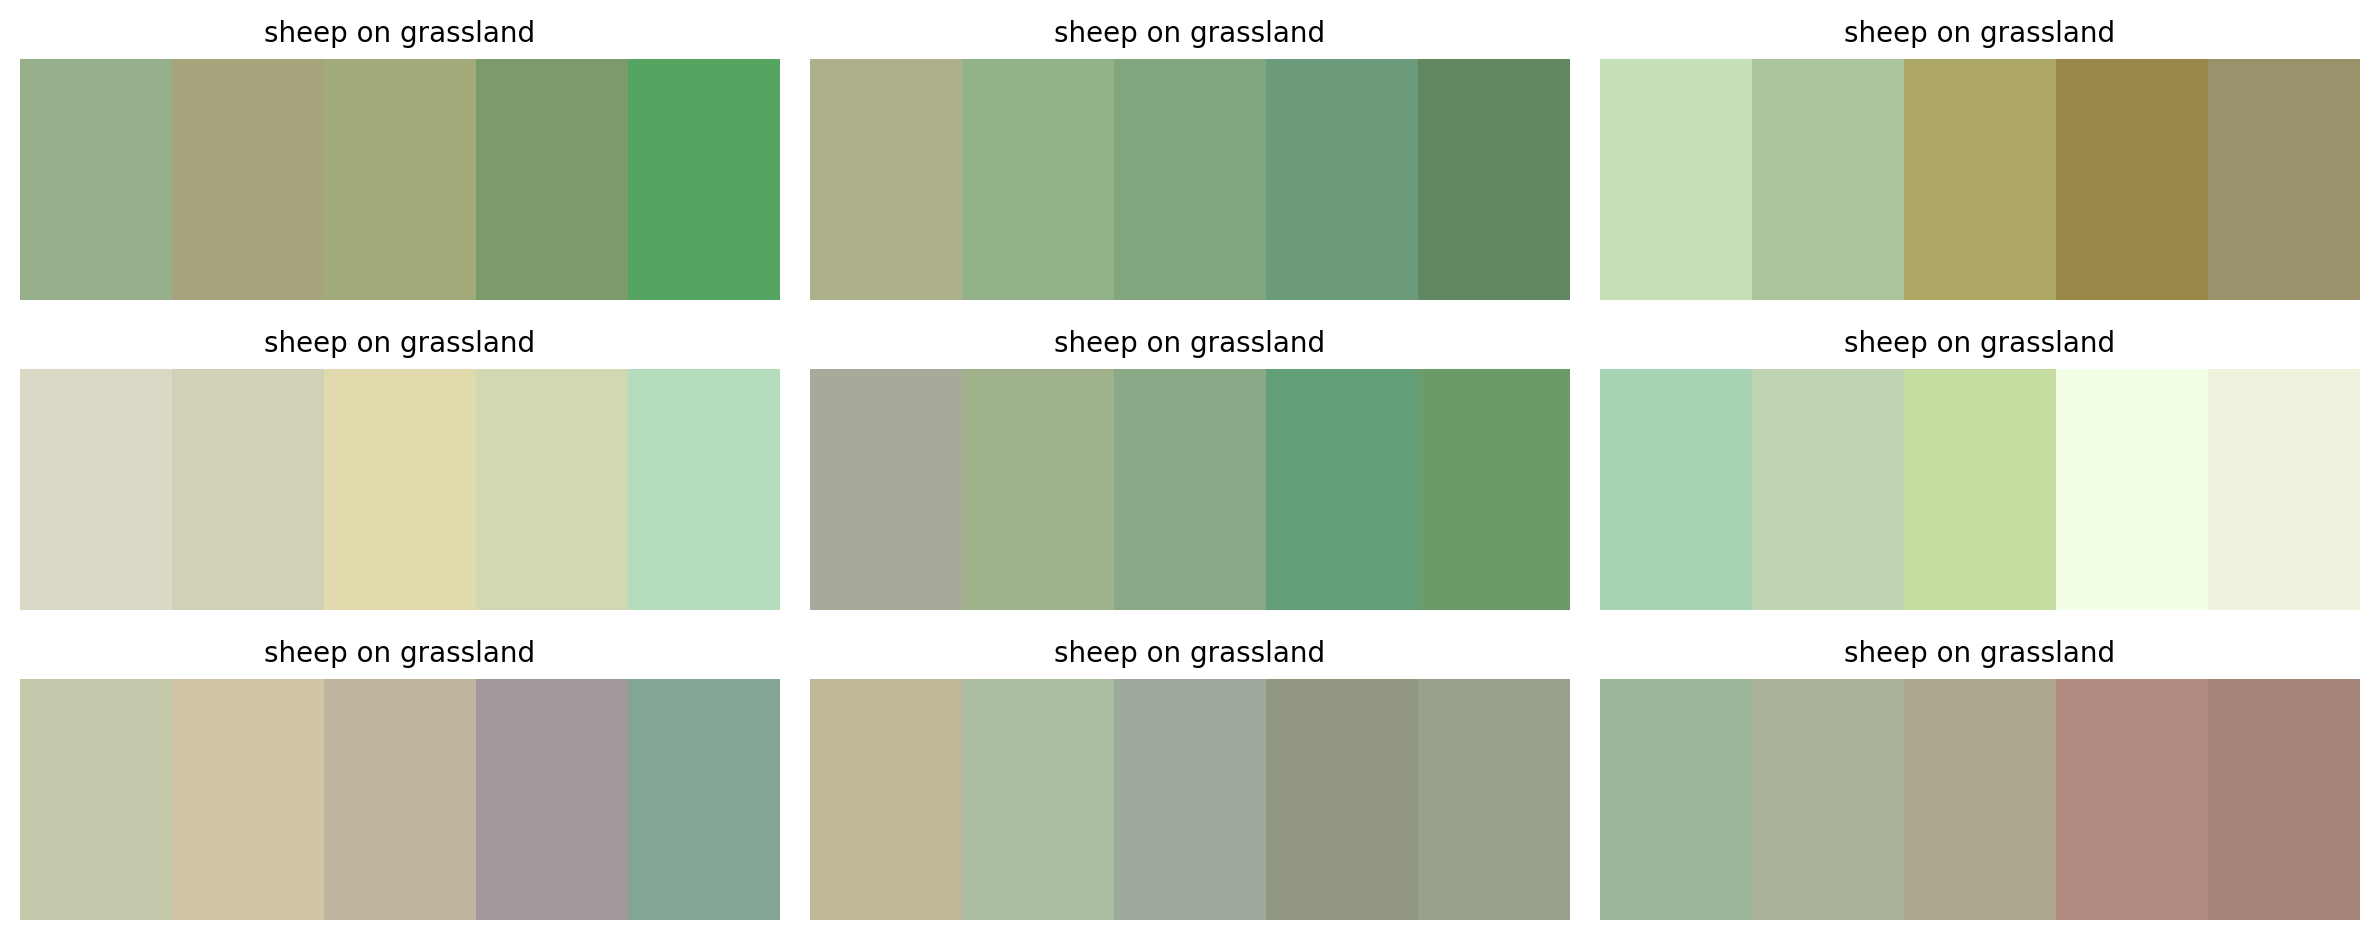

In [ ]:
prompts = number_of_palettes * [text_prompt]

palettes = []
for prompt in prompts:
    hex_list = generate_palette(model, prompt, palette_size, deterministic=False)
    palettes.append({"text": prompt, "palette": hex_list})

print(palettes)

render_palettes(palettes)